# Assignment 5

Deadline: 30.06.2026 12:00 CEST

## Task

Develop an investment strategy for the Swiss equity market, backtest it using the provided datasets (i.e., `market_data.parquet`, `jkp_data.parquet`, `spi_index.csv`) and analyze its performance by benchmarking it against the Swiss Performance Index (SPI). Build on the existing qpmwp-course codebase and extend it with any additional components required. Summarize your approach and findings in a written report.

### Coding (15 points)



- Selection:
  Use some of the existing selection item builder functions (in `bibfn_selection.py`, applied via `SelectionItemBuilder`) to filter stocks based on specific criteria, and/or implement your own filters (e.g., exclude low-quality or high-volatility stocks).

- Optimization Data & Constraints:
  Use the implemented functions for preparing optimization inputs (in `bibfn_optimization_data.py`, applied via `OptimizationItemBuilder`) and for specifying constraints such as stock, sector, or factor exposure limits (in `bibfn_constraints.py`, applied via `OptimizationItemBuilder`). Extend these with your own functions where appropriate.

- Signal Generation:
  Use a machine learning method to estimate optimization inputs such as expected returns or risk. Possible approaches include regression, classification, or learning-to-rank models. A good starting point is the demo notebook `xsection_regressor.ipynb` which shows how to generate predictive signals. Use jkp_data as features or engineer your own (e.g., technical indicators from returns or prices). Alternatively, or in combination, you may use a factor model to construct the optimization inputs.

- Optimization Model:
  Use an optimization model to determine portfolio weights. You may rely on an existing class (e.g., `MeanVariance`, `LeastSquares`, or `BlackLitterman`) or implement a custom model. If you choose to create a custom optimization model, develop a class inheriting from `Optimization` and ensure implement the methods `set_objective` (to construct the coefficients of the objective function) and `solve` (to run the optimization).

- Simulation:
  Backtest the strategy and simulate portfolio returns, incorporating fixed costs of 1% per year and transaction costs of 0.2% per rebalancing.


### Report (15 points):

Produce an HTML report (for example, by converting a .ipynb notebook to HTML) containing:

- High-level strategy overview: A clear description of the investment strategy and its rationale.

- Detailed explanation of the backtesting steps: A step-by-step explanation of the backtest design, including model choices and implementation details (e.g., the machine learning method or factor model used).

- Backtesting results:
    
    - Charts: Visualizations such as cumulative performance, rolling 3-year returns, etc.
    - Descriptive statistics: Key statistics such as mean, standard deviation, drawdown, turnover, and Sharpe ratio (or any other relevant metric) for the full backtest period as well as for subperiods (e.g., the last 5 years, or during bull vs. bear market phases).
    - Compare your strategy against the SPI.


# Assignment 5 — Robust Low-Risk Core with Learning-to-Rank Multi-Factor Tilt

Deadline: 30.06.2026, 12:00 CEST

**Submitted by:** Luca Francesco Besomi, 20-206-769, lucafrancesco.besomi@uzh.ch; Francesco Carlo Filippo Orsingher, 21-986-971, francescocarlofilippo.orsingher@uzh.ch; Devin Liam Rohr, 16-454-753, devinliam.rohr@uzh.ch; Tamas Terner, 19-755-495, tamas.terner@uzh.ch

**Strategy thesis:** In a single-country equity universe (~157 names), the most robust out-of-sample edge lies on the *risk side*, not on expected returns (Chopra–Ziemba 1993; low-volatility anomaly). The backbone of the strategy is a **risk-based allocator** (minimum-variance with Ledoit-Wolf shrinkage) that historically beats cap-weighted on Sharpe and drawdown. On top of this core we mount a **cross-sectional multi-factor tilt** estimated via a **learning-to-rank model** (XGBRanker / LambdaMART). Extra return comes from the tilt; stability and low drawdown come from the core; the net result is won through **turnover control**.

We evaluate four strategy rungs — each adding one ingredient — so that every performance difference is attributable to a single cause:

| Rung | Description |
|------|------------|
| **S0** | SPI benchmark |
| **S1** | Min-Variance core (Ledoit-Wolf Σ, constraints, no signal) |
| **S2** | Core + linear multi-factor z-score tilt |
| **S3** | Core + Learning-to-Rank tilt (XGBRanker) |
| **S4** | Full model: LTR tilt + regime-aware risk scaling + turnover penalty |


## 1. Setup & Data Loading

In [181]:
# Standard library imports
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Third party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

# Add project root to path
project_root = os.path.dirname(os.path.abspath(''))
src_path = os.path.join(project_root, 'src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules
from helper_functions import load_pickle, load_data_spi, align_market_data_with_jkp_data, to_numpy
from estimation.covariance import Covariance, CovarianceSpecification, cov_pearson, is_pos_def, make_pos_def
from estimation.expected_return import ExpectedReturn
from optimization.optimization import (
    Optimization, Objective, OptimizationParameter, MeanVariance, MinVariance
)
from optimization.optimization_data import OptimizationData
from optimization.constraints import Constraints
from optimization.quadratic_program import QuadraticProgram
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder, OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps, bibfn_selection_min_volume, bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series, bibfn_bm_series, bibfn_cap_weights, bibfn_scores,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint, bibfn_box_constraints, bibfn_turnover_constraint,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest


## Constants & Data Loading


In [182]:
PATH_TO_DATA = os.path.join(os.getcwd(), '..', 'data') + os.sep
SAVE_PATH = os.path.join(os.getcwd(), '..', 'results') + os.sep

In [183]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path=f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path=f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path='../data/')

# Remove duplicate index entries
market_data = market_data[~market_data.index.duplicated(keep='last')]

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(
    market_data=market_data, jkp_data=jkp_data
)

# Instantiate BacktestData
data = BacktestData()
data.market_data = market_data_ffill
data.jkp_data = jkp_data
data.bm_series = spi

## Rebalancing Grid

We rebalance quarterly (every 3 months) on JKP data dates, starting from 2002 onward.


In [184]:
n_month = 3
jkp_data_dates = (
    jkp_data.index.get_level_values('date').unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [d for d in rebdates if d > '2002-01-01']
print(f"Number of rebalancing dates: {len(rebdates)}")
print(f"First: {rebdates[0]}, Last: {rebdates[-1]}")

Number of rebalancing dates: 89
First: 2002-01-31, Last: 2024-01-31


## Feature Definitions

JKP characteristics used as inputs to the ML signal (§4.3 of the strategy document). These span momentum, value, quality, profitability, investment, leverage, and accruals — chosen for economic rationale and known cross-sectional predictive power.


In [185]:
FEATURE_FIELDS = [
    'ret_6_1', 'ret_12_1',                # momentum (skip-month)
    'be_me',                               # value
    'qmj', 'qmj_safety', 'qmj_growth',   # quality
    'gp_at', 'op_at',                      # profitability
    'at_gr1',                              # investment
    'debt_me',                             # leverage
    'oaccruals_at',                        # accruals
]

# Verify all features exist in jkp_data
missing = [f for f in FEATURE_FIELDS if f not in jkp_data.columns]
if missing:
    print(f"WARNING — missing fields: {missing}")
    FEATURE_FIELDS = [f for f in FEATURE_FIELDS if f not in missing]
print(f"Using {len(FEATURE_FIELDS)} features: {FEATURE_FIELDS}")

Using 11 features: ['ret_6_1', 'ret_12_1', 'be_me', 'qmj', 'qmj_safety', 'qmj_growth', 'gp_at', 'op_at', 'at_gr1', 'debt_me', 'oaccruals_at']


## 2. Covariance Estimation - Ledoit-Wolf Shrinkage

The sample covariance matrix is noisy and near-singular along low-eigenvalue directions - exactly where the minimum-variance optimizer loads weight (Σ⁻¹ amplifies small eigenvalues). Ledoit-Wolf shrinkage toward a structured target regularises the estimate in closed form, improving conditioning without ad-hoc tuning. A Ridge fallback (Σ + λI) is applied if the condition number remains extreme after shrinkage.

This is the principled version of the Ridge shrinkage taught in §3 of the course.


In [186]:
# ============================================================
# Section 2 — Ledoit-Wolf Covariance Estimator
# ============================================================

from sklearn.covariance import ledoit_wolf as sklearn_ledoit_wolf


class CovarianceLedoitWolf(Covariance):
    """
    Extends Covariance with Ledoit-Wolf shrinkage (sklearn implementation)
    and an optional Ridge regularisation fallback when cond(Σ) is too high.
    """

    def __init__(self, ridge_threshold=1e8, ridge_lambda=1e-4, **kwargs):
        spec = CovarianceSpecification(method='ledoit_wolf', check_positive_definite=True)
        super().__init__(spec=spec, **kwargs)
        self.ridge_threshold = ridge_threshold
        self.ridge_lambda = ridge_lambda
        self.shrinkage_history = []

    def estimate(self, X, inplace=True):
        if isinstance(X, pd.DataFrame):
            cols = X.columns
            X_arr = X.values
        else:
            cols = None
            X_arr = X

        # Ledoit-Wolf shrinkage (sklearn: shrinks toward scaled identity)
        cov_shrunk, shrinkage = sklearn_ledoit_wolf(X_arr)
        self.shrinkage_history.append(shrinkage)

        # Ridge add-on if condition number is still too high
        cn = np.linalg.cond(cov_shrunk)
        if cn > self.ridge_threshold:
            cov_shrunk += self.ridge_lambda * np.eye(cov_shrunk.shape[0])

        # Ensure positive-definiteness
        if not is_pos_def(cov_shrunk):
            cov_shrunk = make_pos_def(cov_shrunk)

        if cols is not None:
            cov_shrunk = pd.DataFrame(cov_shrunk, index=cols, columns=cols)

        if inplace:
            self.matrix = cov_shrunk
            return None
        else:
            return cov_shrunk


# Quick sanity check
return_series = data.get_return_series(weekdays_only=False)
sample_date = '2010-01-31'
end = pd.Timestamp(sample_date)
start = end - pd.DateOffset(years=3)
sample_returns = return_series.loc[start:end].dropna(axis=1, how='all').fillna(0)

cov_lw = CovarianceLedoitWolf()
sigma = cov_lw.estimate(sample_returns, inplace=False)
print(f"Sample covariance shape: {sigma.shape}")
print(f"Condition number: {np.linalg.cond(sigma):.0f}")
print(f"Shrinkage intensity: {cov_lw.shrinkage_history[-1]:.4f}")
print(f"Positive definite: {is_pos_def(sigma.values if isinstance(sigma, pd.DataFrame) else sigma)}")


Sample covariance shape: (210, 210)
Condition number: 467
Shrinkage intensity: 0.0788
Positive definite: True


## 3. Custom Selection Functions

Beyond the existing `gaps` and `min_volume` filters, we add:

1. **`feature_coverage`** — keeps only stocks with all ML features non-NA at the rebalancing date. This ensures the ML universe equals the backtest universe: the optimizer never asks the signal to rank a stock it hasn't scored.

2. **`volatility_screen`** *(optional)* — excludes the top decile by trailing realised volatility. Economically motivated: extremely volatile stocks carry tail risk that the minimum-variance core cannot fully offset, and their factor exposures are noisy.


In [187]:
# ============================================================
# Section 3 — Custom Selection Functions
# ============================================================

def bibfn_selection_feature_coverage(bs, rebdate, **kwargs):
    """
    Keeps only stocks that have ALL specified features non-NA at the
    rebalancing date. Ensures ML universe = backtest universe.
    
    Returns a DataFrame with 'binary' column (required by SelectionItemBuilder).
    """
    fields = kwargs.get('fields', FEATURE_FIELDS)

    jkp = bs.data.jkp_data
    rebdate_ts = pd.Timestamp(rebdate)

    # Filter rows prior to rebdate within one year
    df = jkp[fields]
    filtered_df = df.loc[
        (df.index.get_level_values('date') <= rebdate) &
        (df.index.get_level_values('date') >= rebdate_ts - pd.Timedelta(days=365))
    ]

    # Extract last available value per stock
    scores = filtered_df.groupby('id').last()

    # Output: binary = 1 if all fields are non-NA
    filter_values = scores.copy()
    filter_values['binary'] = scores.notna().all(axis=1).astype(int)

    return filter_values


def bibfn_selection_volatility_screen(bs, rebdate, **kwargs):
    """
    Excludes the top decile by trailing realised volatility.
    High-vol stocks carry tail risk and noisy factor exposures.
    
    Returns a DataFrame with 'values' and 'binary' columns.
    """
    width = kwargs.get('width', 365)
    quantile_cutoff = kwargs.get('quantile_cutoff', 0.90)

    rebdate_ts = pd.Timestamp(rebdate)

    # Get return series
    return_series = bs.data.get_return_series(
        end_date=rebdate,
        width=width,
        weekdays_only=True,
        fillna_value=0,
    )

    # Realised volatility (annualised)
    vol = return_series.std() * np.sqrt(252)
    threshold = vol.quantile(quantile_cutoff)

    # Keep stocks below the threshold
    filter_values = pd.DataFrame({
        'values': vol,
        'binary': (vol <= threshold).astype(int),
    }, index=vol.index)

    return filter_values


print("Custom selection functions defined: bibfn_selection_feature_coverage, bibfn_selection_volatility_screen")

Custom selection functions defined: bibfn_selection_feature_coverage, bibfn_selection_volatility_screen


## 4. Custom Optimization Model — `MinVarianceTilt`

The optimizer solves a quadratic program at each rebalancing date that combines three terms:

1. **Risk (core):** $w^\top \Sigma w$ — minimises portfolio variance using the Ledoit-Wolf covariance estimate. When the tilt intensity $\gamma = 0$ this recovers the pure minimum-variance portfolio (rung S1), serving as a sanity check.

2. **Signal tilt:** $-\gamma \, s^\top w$ — tilts toward stocks ranked highly by the signal (linear z-score or LTR output). The signal $s$ is standardised cross-sectionally so that $\gamma$ has a stable scale over time. The intensity $\gamma$ is kept low — the centre of gravity remains on risk.

3. **Turnover penalty:** $\lambda_{\text{TO}} \|w - w_{\text{prev}}\|_1$ — linearised via auxiliary variables $w^+, w^-$ (§3 of the course). Controls trading costs, which are the true battlefield in a ~157-name universe with 1% p.a. fixed costs + 0.2% per rebalancing.

**Constraints** $\Omega$: fully invested ($\sum w_i = 1$), long-only ($w_i \geq 0$), box bounds per name (e.g. $w_i \leq 5\%$), and optional sector band constraints relative to the benchmark.

The class inherits from `Optimization` and implements `set_objective` and `solve` as required by the rubric.

In [188]:
class MinVarianceTilt(Optimization):
    """
    Minimum-variance core with optional signal tilt and turnover penalty.
    
    γ = 0  →  pure min-variance (S1)
    γ > 0  →  min-var + tilt (S2/S3/S4)
    turnover_penalty > 0  →  L1 penalty on weight changes (S4)
    """

    def __init__(self,
                 covariance=None,
                 gamma=0.0,
                 turnover_penalty=0.0,
                 constraints=None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            turnover_penalty=turnover_penalty,
            **kwargs,
        )
        self.covariance = CovarianceLedoitWolf() if covariance is None else covariance
        self.gamma = gamma

    def set_objective(self, optimization_data):
        X = optimization_data['return_series']

        # Drop duplicate columns if any
        X = X.loc[:, ~X.columns.duplicated()]

        # Estimate covariance (Ledoit-Wolf)
        covmat = self.covariance.estimate(X=X, inplace=False)

        # Quadratic term: P = 2Σ
        P = covmat * 2

        # Linear term: q = -γ * s  (or zero if no signal / γ=0)
        n = X.shape[1]
        if self.gamma > 0 and 'scores' in optimization_data.keys():
            scores = optimization_data['scores']
            if isinstance(scores, pd.DataFrame):
                scores = scores.mean(axis=1)

            # Drop duplicate index entries
            scores = scores[~scores.index.duplicated()]

            # Cross-sectional z-score for stable γ scale
            s = (scores - scores.mean()) / (scores.std() + 1e-10)

            # Align with return_series columns
            s = s.reindex(X.columns).fillna(0)

            q = (-self.gamma * s).values
        else:
            q = np.zeros(n)

        # Ensure float64 numpy arrays for the QP solver
        P_np = np.asarray(P, dtype=np.float64)
        q_np = np.asarray(q, dtype=np.float64).ravel()
        self.objective = Objective(P=P_np, q=q_np)

        return None


    def solve(self):
        return super().solve()


print("MinVarianceTilt optimizer defined.")

MinVarianceTilt optimizer defined.


### Sanity Check — $\gamma = 0$ recovers pure Min-Variance

We verify that `MinVarianceTilt(gamma=0)` produces the same weights as the built-in `MinVariance` class on a single rebalancing date.

In [189]:
# Build a small test: one rebalancing date, same selection & data
test_date = '2010-01-31'
end_ts = pd.Timestamp(test_date)
start_ts = end_ts - pd.DateOffset(years=3)

return_series = data.get_return_series(weekdays_only=False)
test_ret = return_series.loc[start_ts:end_ts].dropna(axis=1, how='all').fillna(0)

# Keep only stocks with enough data (>100 obs)
test_ret = test_ret.loc[:, test_ret.count() > 100]
ids = test_ret.columns.tolist()

# Shared constraints
def make_test_constraints(ids):
    c = Constraints(ids=ids)
    c.add_budget(rhs=1, sense='=')
    c.add_box(box_type='LongOnly', upper=0.05)
    return c

# Build OptimizationData properly (no positional args, set key after init)
od = OptimizationData(align=False)
od['return_series'] = test_ret

# --- Built-in MinVariance ---
opt_builtin = MinVariance(
    covariance=CovarianceLedoitWolf(),
    constraints=make_test_constraints(ids),
)
opt_builtin.set_objective(od)
opt_builtin.solve()
w_builtin = pd.Series(opt_builtin.results['weights'])

# --- Our MinVarianceTilt with γ=0 ---
opt_custom = MinVarianceTilt(
    gamma=0.0,
    constraints=make_test_constraints(ids),
)
opt_custom.set_objective(od)
opt_custom.solve()
w_custom = pd.Series(opt_custom.results['weights'])

# Compare
diff = (w_builtin - w_custom).abs()
print(f"Max weight difference (γ=0 vs MinVariance): {diff.max():.2e}")
print(f"Sum of weights — builtin: {w_builtin.sum():.6f}, custom: {w_custom.sum():.6f}")
print(f"Number of nonzero positions — builtin: {(w_builtin > 1e-6).sum()}, custom: {(w_custom > 1e-6).sum()}")
print("✓ Sanity check passed." if diff.max() < 1e-4 else "✗ Mismatch detected — investigate.")

Max weight difference (γ=0 vs MinVariance): 0.00e+00
Sum of weights — builtin: 1.000000, custom: 1.000000
Number of nonzero positions — builtin: 210, custom: 210
✓ Sanity check passed.


## 5. Signal Generation - Linear Multi-Factor Z-Score (Rung S2)

The linear signal is a simple equal-weighted composite of cross-sectionally standardised JKP characteristics. At each rebalancing date we:

1. Retrieve the JKP features for selected stocks.
2. Z-score each feature cross-sectionally (subtract mean, divide by std).
3. Winsorise at ±3σ to limit the influence of outliers.
4. Sign-flip features where the economic prior implies a *negative* premium (e.g. `at_gr1` — high asset growth predicts underperformance; `debt_me` — high leverage is risky; `oaccruals_at` — high accruals signal low earnings quality).
5. Average across features to obtain a single composite score per stock.

This baseline serves two purposes: (i) it is the tilt for rung S2, isolating the contribution of a linear factor signal; (ii) it is the benchmark against which the LTR model (S3) is compared to quantify the value of non-linearity.

In [190]:
# ============================================================
# Section 5 — Linear Z-Score Signal Builder
# ============================================================

# Features where higher values predict LOWER returns → flip sign
NEGATIVE_PREMIUM_FIELDS = ['at_gr1', 'debt_me', 'oaccruals_at']


def compute_linear_signal(jkp_data, rebdate, selected_ids, fields=None):
    """
    Computes a cross-sectional z-score composite signal at a given date.
    
    Returns a pd.Series of composite scores indexed by stock id.
    """
    if fields is None:
        fields = FEATURE_FIELDS

    rebdate_ts = pd.Timestamp(rebdate)

    # Get JKP data at or just before the rebalancing date
    available_dates = jkp_data.index.get_level_values('date').unique()
    prior = available_dates[available_dates <= rebdate_ts]
    if len(prior) == 0:
        return pd.Series(dtype=float)
    use_date = prior[-1]

    jkp_at_date = jkp_data.loc[use_date]

    # Filter to selected stocks and available fields
    valid_fields = [f for f in fields if f in jkp_at_date.columns]
    scores_raw = jkp_at_date.loc[
        jkp_at_date.index.isin(selected_ids), valid_fields
    ].copy()

    if scores_raw.empty:
        return pd.Series(dtype=float)

    # Cross-sectional z-score
    scores_z = (scores_raw - scores_raw.mean()) / (scores_raw.std() + 1e-10)

    # Winsorise at ±3
    scores_z = scores_z.clip(lower=-3, upper=3)

    # Sign-flip negative-premium fields
    for f in NEGATIVE_PREMIUM_FIELDS:
        if f in scores_z.columns:
            scores_z[f] = -scores_z[f]

    # Equal-weighted composite
    composite = scores_z.mean(axis=1)

    # Drop duplicate stock IDs
    composite = composite[~composite.index.duplicated()]

    return composite


def bibfn_linear_signal(bs, rebdate, **kwargs):
    """
    OptimizationItemBuilder function: computes the linear z-score
    composite and stores it in bs.optimization_data['scores'].
    """
    fields = kwargs.get('fields', FEATURE_FIELDS)
    selected_ids = bs.selection.selected

    signal = compute_linear_signal(
        jkp_data=bs.data.jkp_data,
        rebdate=rebdate,
        selected_ids=selected_ids,
        fields=fields,
    )

    # Store as a DataFrame (expected by MinVarianceTilt.set_objective)
    bs.optimization_data['scores'] = signal.to_frame(name='linear_signal')
    return None


print("Linear signal builder defined: compute_linear_signal, bibfn_linear_signal")

Linear signal builder defined: compute_linear_signal, bibfn_linear_signal


### Signal Preview

Quick look at the composite signal distribution at a sample rebalancing date, to verify it is centred at zero and reasonably shaped.

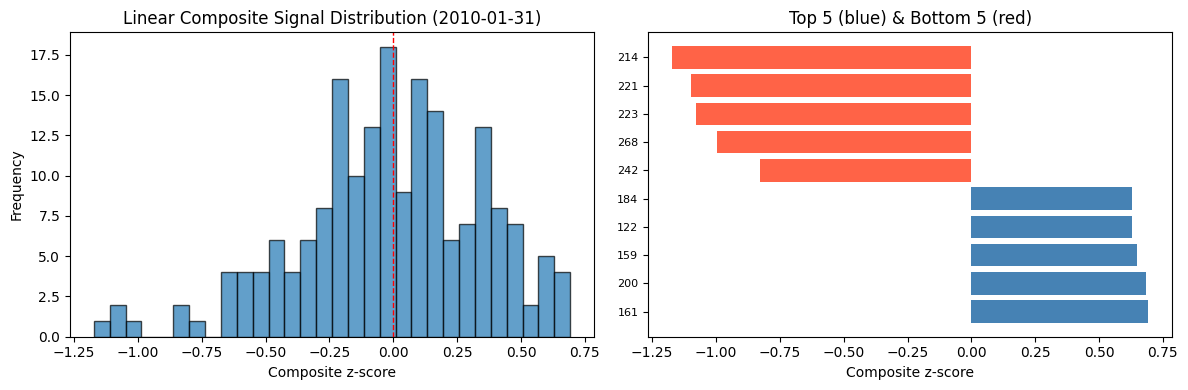

Signal coverage: 191 / 269 stocks
Mean: -0.0150, Std: 0.3637


In [191]:
# Preview the signal at a sample date
sample_ids = return_series.loc[:pd.Timestamp('2010-01-31')].dropna(axis=1, how='all').columns.tolist()
sample_signal = compute_linear_signal(
    jkp_data=jkp_data,
    rebdate='2010-01-31',
    selected_ids=sample_ids,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sample_signal.dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Linear Composite Signal Distribution (2010-01-31)')
axes[0].set_xlabel('Composite z-score')
axes[0].set_ylabel('Frequency')

# Show top and bottom 5
ranked = sample_signal.sort_values(ascending=False)
top_bottom = pd.concat([ranked.head(5), ranked.tail(5)])
colors = ['steelblue'] * 5 + ['tomato'] * 5
axes[1].barh(range(len(top_bottom)), top_bottom.values, color=colors)
axes[1].set_yticks(range(len(top_bottom)))
axes[1].set_yticklabels(top_bottom.index, fontsize=8)
axes[1].set_title('Top 5 (blue) & Bottom 5 (red)')
axes[1].set_xlabel('Composite z-score')

plt.tight_layout()
plt.show()

print(f"Signal coverage: {sample_signal.notna().sum()} / {len(sample_ids)} stocks")
print(f"Mean: {sample_signal.mean():.4f}, Std: {sample_signal.std():.4f}")

## 6. Signal Generation — Learning-to-Rank (Rungs S3 / S4)

The LTR signal replaces the linear composite with a non-linear ranking model. Key design choices:

- **Model:** `XGBRanker` with `objective='rank:ndcg'`, `ndcg_exp_gain=False` — a listwise loss that rewards correct *ordering* and up-weights the top of the list, which is exactly what a long-only quintile strategy needs.
- **Features:** The same JKP characteristics as the linear signal (momentum, value, quality, profitability, investment, leverage, accruals), z-scored and winsorised cross-sectionally per date.
- **Labels:** Rank percentile of next-month forward returns (bounded, ordinal — avoids NDCG gain explosion on raw ranks).
- **Walk-forward:** Rolling 3-year training window, stride = 1 quarter. The model is retrained at every stride step; no future information ever enters the training set.
- **Diagnostics:** Out-of-sample Spearman IC per date, with t-statistic. An IC > 0.15 triggers a leakage alarm (§10 of the strategy document).

The existing `XGBRankerSklearnWrapper` and `ObservationGridRollingSplit` from the course codebase are reused.

In [192]:
# ============================================================
# Section 6 — Learning-to-Rank Signal
# ============================================================

from scipy.stats import rankdata, spearmanr
from xgboost import XGBRanker
from ml.model.xgb_ranker_wrapper import XGBRankerSklearnWrapper
from ml.splitters.rolling_timeseries_split import iter_rolling_dates_from_grid

# ------------------------------------------------------------------
# Step 1: Build the (DATE, ID) panel of features and labels
# ------------------------------------------------------------------

def build_ltr_panel(jkp_data, market_data, feature_fields, label_horizon_months=3):
    """
    Constructs the feature matrix X and label vector y for the LTR model.
    
    X: JKP features, z-scored and winsorised cross-sectionally per date.
    y: Rank percentile of forward returns over `label_horizon_months`.
    
    Both indexed by (DATE, ID) MultiIndex.
    """
    # --- Features ---
    dates = jkp_data.index.get_level_values('date').unique().sort_values()
    
    panels = []
    for dt in dates:
        chunk = jkp_data.loc[dt, feature_fields].copy()
        chunk.index = pd.MultiIndex.from_product(
            [[dt], chunk.index], names=['DATE', 'ID']
        )
        panels.append(chunk)
    
    X_raw = pd.concat(panels)
    
    # Cross-sectional z-score + winsorise per date
    X = X_raw.groupby(level='DATE').transform(
        lambda x: ((x - x.mean()) / (x.std() + 1e-10)).clip(-3, 3)
    )
    
    # Sign-flip negative-premium features
    for f in NEGATIVE_PREMIUM_FIELDS:
        if f in X.columns:
            X[f] = -X[f]
    
    # --- Labels: forward return rank percentile ---
    # Pivot price to wide format and compute daily returns
    price = market_data['price'].groupby(level=['date', 'id']).last().unstack('id')
    ret_daily = price.pct_change()
    
    # Compound to monthly
    ret_monthly = (1 + ret_daily).resample('ME').prod() - 1
    
    # Forward return over label_horizon_months
    fwd_ret = ret_monthly.rolling(window=label_horizon_months).apply(
        lambda x: (1 + x).prod() - 1, raw=False
    ).shift(-label_horizon_months)
    
    # Map to JKP dates and rank cross-sectionally
    y_parts = []
    for dt in dates:
        # Find the closest monthly return date
        month_dates = fwd_ret.index[fwd_ret.index >= dt]
        if len(month_dates) == 0:
            continue
        use_date = month_dates[0]
        
        fwd = fwd_ret.loc[use_date].dropna()
        if len(fwd) < 5:
            continue
        # Rank percentile (0-1)
        ranks = pd.Series(
            rankdata(fwd.values, method='average') / (len(fwd) + 1),
            index=fwd.index,
            name='fwd_ret_rank'
        )
        ranks.index = pd.MultiIndex.from_product(
            [[dt], ranks.index], names=['DATE', 'ID']
        )
        y_parts.append(ranks)
    
    y = pd.concat(y_parts)
    
    # Align X and y
    common_idx = X.index.intersection(y.index)
    X = X.loc[common_idx].dropna()
    y = y.loc[X.index]
    
    return X, y


print("Building LTR panel (this takes a moment)...")
X_panel, y_panel = build_ltr_panel(
    jkp_data=jkp_data,
    market_data=market_data,
    feature_fields=FEATURE_FIELDS,
    label_horizon_months=3,
)
print(f"Panel shape — X: {X_panel.shape}, y: {y_panel.shape}")
print(f"Date range: {X_panel.index.get_level_values('DATE').min().strftime('%Y-%m-%d')} "
      f"to {X_panel.index.get_level_values('DATE').max().strftime('%Y-%m-%d')}")
print(f"Average stocks per date: {X_panel.groupby(level='DATE').size().mean():.0f}")

Building LTR panel (this takes a moment)...
Panel shape — X: (34874, 11), y: (34874,)
Date range: 1994-04-30 to 2024-01-31
Average stocks per date: 97


### Walk-Forward Training

We train `XGBRanker` on a rolling 3-year window (36 monthly observations), stride 1 quarter, with a 1-month gap between train and test to avoid label leakage. At each step the model produces an out-of-sample ranking score for every stock in the test period.

In [193]:
# ------------------------------------------------------------------
# Step 2: Walk-forward LTR training
# ------------------------------------------------------------------

def train_ltr_walkforward(X, y, train_window_obs=36, retrain_stride=3, 
                          skip_obs=1):
    """
    Walk-forward training of XGBRanker. Returns a DataFrame of 
    out-of-sample predictions indexed by (DATE, ID).
    """
    obs_dates = X.index.get_level_values('DATE').unique().sort_values()
    
    model = XGBRankerSklearnWrapper(
        objective='rank:ndcg',
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=5,
        subsample=0.8,
        ndcg_exp_gain=False,
        verbosity=0,
    )
    
    all_preds = []
    split_count = 0
    
    for train_start, train_end, test_start, test_end in iter_rolling_dates_from_grid(
        observation_dates=obs_dates,
        train_window_obs=train_window_obs,
        skip_obs_between_train_test=skip_obs,
        retrain_stride=retrain_stride,
    ):
        # Select train / test data
        dates_level = X.index.get_level_values('DATE')
        
        train_mask = (dates_level >= train_start) & (dates_level <= train_end)
        test_mask = (dates_level >= test_start) & (dates_level <= test_end)
        
        X_train, y_train = X[train_mask], y[train_mask]
        X_test = X[test_mask]
        
        if len(X_train) < 100 or len(X_test) == 0:
            continue
        
        # Drop rows with NaN
        valid_train = X_train.notna().all(axis=1) & y_train.notna()
        X_train = X_train[valid_train]
        y_train = y_train[valid_train]
        
        if len(X_train) < 50:
            continue
        
        # Fit
        from sklearn.base import clone
        m = clone(model)
        m.fit(X_train, y_train)
        
        # Predict
        valid_test = X_test.notna().all(axis=1)
        X_test_clean = X_test[valid_test]
        if len(X_test_clean) == 0:
            continue
            
        preds = pd.Series(
            m.predict(X_test_clean),
            index=X_test_clean.index,
            name='ltr_score'
        )
        all_preds.append(preds)
        split_count += 1
    
    print(f"Completed {split_count} walk-forward splits.")
    
    if len(all_preds) == 0:
        return pd.Series(dtype=float, name='ltr_score')
    
    return pd.concat(all_preds)


print("Training LTR walk-forward (this may take several minutes)...")
ltr_predictions = train_ltr_walkforward(
    X_panel, y_panel,
    train_window_obs=36,
    retrain_stride=3,
    skip_obs=1,
)
print(f"Total OOS predictions: {len(ltr_predictions)}")
print(f"Dates covered: {ltr_predictions.index.get_level_values('DATE').nunique()}")

Training LTR walk-forward (this may take several minutes)...
Completed 107 walk-forward splits.
Total OOS predictions: 33420
Dates covered: 321


### Out-of-Sample Diagnostics

We compute the Spearman rank IC (information coefficient) between the model's predicted scores and the realised forward returns. The IC measures whether the model's cross-sectional ranking aligns with actual outcomes.

**Leakage alarm:** an average IC > 0.15 would indicate information leakage rather than genuine skill — we flag this and audit before proceeding.

OOS Spearman IC — Mean: 0.0745, Std: 0.1423
t-stat: 9.38, Hit rate: 71.3%
✓ Signal is statistically significant (t > 1.5).


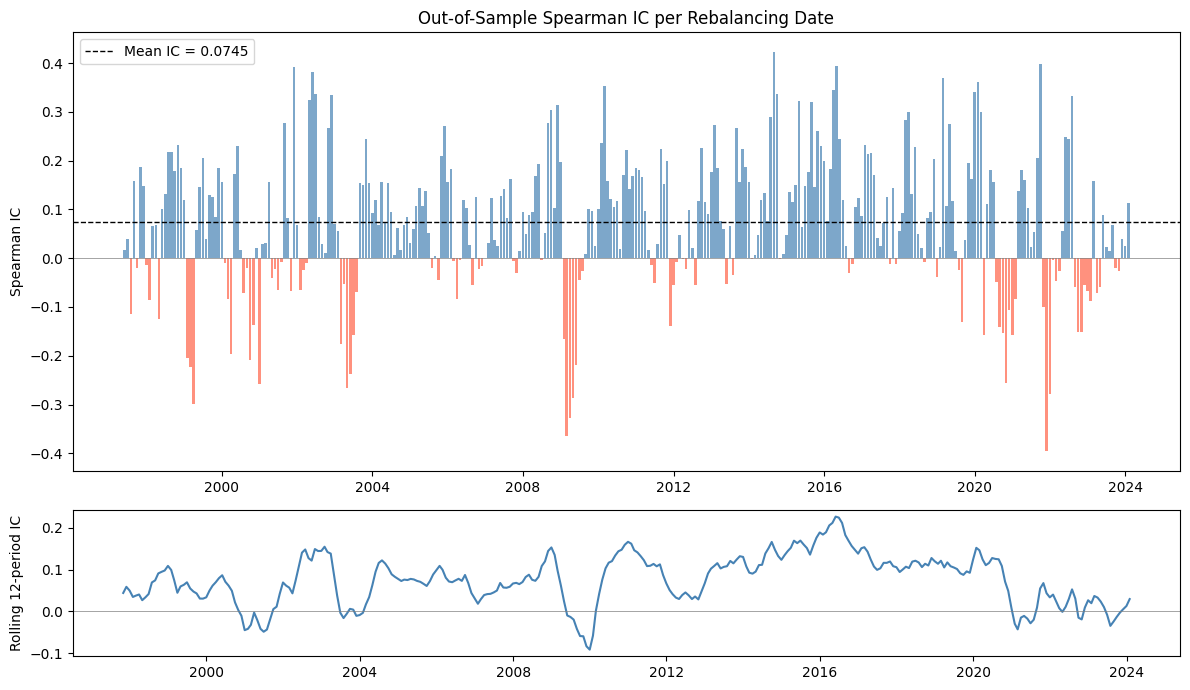

In [194]:
# ------------------------------------------------------------------
# Step 3: OOS diagnostics — Spearman IC
# ------------------------------------------------------------------

def compute_oos_ic(predictions, y_actual):
    """
    Computes per-date Spearman rank IC between predictions and actuals.
    """
    common = predictions.index.intersection(y_actual.index)
    preds = predictions.loc[common]
    actuals = y_actual.loc[common]
    
    ic_per_date = {}
    for dt in preds.index.get_level_values('DATE').unique():
        p = preds.loc[dt]
        a = actuals.loc[dt]
        # Align
        common_ids = p.index.intersection(a.index)
        if len(common_ids) < 10:
            continue
        corr, _ = spearmanr(p.loc[common_ids], a.loc[common_ids])
        ic_per_date[dt] = corr
    
    return pd.Series(ic_per_date, name='IC')


ic_series = compute_oos_ic(ltr_predictions, y_panel)

# Statistics
ic_mean = ic_series.mean()
ic_std = ic_series.std()
ic_tstat = ic_mean / (ic_std / np.sqrt(len(ic_series))) if ic_std > 0 else 0
ic_hit_rate = (ic_series > 0).mean()

print(f"OOS Spearman IC — Mean: {ic_mean:.4f}, Std: {ic_std:.4f}")
print(f"t-stat: {ic_tstat:.2f}, Hit rate: {ic_hit_rate:.1%}")

if ic_mean > 0.15:
    print("⚠ LEAKAGE ALARM: IC > 0.15 — audit label shift before proceeding!")
elif ic_tstat > 1.5:
    print("✓ Signal is statistically significant (t > 1.5).")
else:
    print("△ Signal is weak (t < 1.5) — proceed with caution, the tilt adds modest value.")

# Plot IC over time
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [3, 1]})

axes[0].bar(ic_series.index, ic_series.values, width=25,
            color=np.where(ic_series > 0, 'steelblue', 'tomato'), alpha=0.7)
axes[0].axhline(ic_mean, color='black', linestyle='--', linewidth=1, label=f'Mean IC = {ic_mean:.4f}')
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].set_title('Out-of-Sample Spearman IC per Rebalancing Date')
axes[0].set_ylabel('Spearman IC')
axes[0].legend()

# Rolling 12-period IC
ic_rolling = ic_series.rolling(12, min_periods=6).mean()
axes[1].plot(ic_rolling.index, ic_rolling.values, color='steelblue', linewidth=1.5)
axes[1].axhline(0, color='grey', linewidth=0.5)
axes[1].set_ylabel('Rolling 12-period IC')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### LTR Signal Builder for the Backtest

We wrap the pre-computed LTR predictions into an `OptimizationItemBuilder`-compatible function. At each rebalancing date, it looks up the most recent OOS score for each selected stock.

In [195]:
# ------------------------------------------------------------------
# Step 4: LTR signal builder for the backtest engine
# ------------------------------------------------------------------

def bibfn_ltr_signal(bs, rebdate, **kwargs):
    """
    OptimizationItemBuilder function: retrieves pre-computed LTR scores
    for the rebalancing date and stores them in bs.optimization_data['scores'].
    """
    predictions = kwargs.get('predictions', ltr_predictions)
    selected_ids = bs.selection.selected
    rebdate_ts = pd.Timestamp(rebdate)
    
    # Find the most recent prediction date <= rebdate
    pred_dates = predictions.index.get_level_values('DATE').unique().sort_values()
    valid_dates = pred_dates[pred_dates <= rebdate_ts]
    
    if len(valid_dates) == 0:
        # Fallback: no LTR prediction available, use zero signal
        bs.optimization_data['scores'] = pd.DataFrame(
            0.0, index=selected_ids, columns=['ltr_score']
        )
        return None
    
    use_date = valid_dates[-1]
    scores = predictions.loc[use_date]
    
    # Filter to selected stocks
    if isinstance(scores, pd.Series):
        scores = scores.reindex(selected_ids)
    else:
        scores = scores.reindex(selected_ids)
    
    # Cross-sectional z-score for stable γ scale
    scores = (scores - scores.mean()) / (scores.std() + 1e-10)
    
    bs.optimization_data['scores'] = scores.to_frame(name='ltr_score')
    return None


print("LTR signal builder defined: bibfn_ltr_signal")
print(f"Predictions available for {ltr_predictions.index.get_level_values('DATE').nunique()} dates")

LTR signal builder defined: bibfn_ltr_signal
Predictions available for 321 dates


## 7. Regime Overlay — Eigenvalue Concentration (Rung S4)

In crisis periods, correlations spike and the market behaves like "a single factor" — the first eigenvalue of the correlation matrix absorbs most of the variance. When this happens, factor signals become unreliable and the minimum-variance core is the safest anchor.

The overlay scales the tilt intensity $\gamma$ based on a **pre-specified, non-tuned** rule:

1. Compute the correlation matrix from trailing returns.
2. Extract the share of variance explained by the first eigenvalue: $\rho_1 = \lambda_1 / \sum_i \lambda_i$.
3. Classify the regime into terciles based on the historical distribution of $\rho_1$:
   - **High concentration** ($\rho_1$ in top tercile) → crisis → $\gamma \downarrow$ (de-risk, lean on core)
   - **Normal** → $\gamma$ at base level
   - **Low concentration** → calm, dispersed market → $\gamma$ at base level (no boost — conservative)

This is **de-risking, not market timing**: the strategy never increases exposure above its base level. The tercile thresholds are computed from a trailing expanding window, so no future information is used.

In [196]:
# ============================================================
# Section 7 — Regime Overlay
# ============================================================

def compute_eigenvalue_concentration(return_series, date, lookback_days=756):
    """
    Computes the share of variance explained by the first eigenvalue
    of the trailing correlation matrix.
    
    Returns rho_1 = lambda_1 / sum(lambda_i), a value in (0, 1].
    High values indicate crisis / one-factor markets.
    """
    end = pd.Timestamp(date)
    start = end - pd.DateOffset(days=lookback_days)
    
    ret = return_series.loc[start:end].dropna(axis=1, how='all')
    
    # Drop columns with too many NaNs, then fill remaining
    min_obs = 60
    ret = ret.loc[:, ret.count() >= min_obs].fillna(0)
    
    if ret.shape[1] < 5 or ret.shape[0] < min_obs:
        return np.nan
    
    # Drop constant columns (zero variance → NaN correlations)
    ret = ret.loc[:, ret.std() > 1e-10]
    
    if ret.shape[1] < 5:
        return np.nan
    
    try:
        corr = ret.corr().values.copy()
        # Replace any remaining NaN/inf with 0 (off-diag) or 1 (diag)
        np.fill_diagonal(corr, 1.0)
        corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
        
        eigenvalues = np.linalg.eigvalsh(corr)
        eigenvalues = np.maximum(eigenvalues, 0)
        
        total = eigenvalues.sum()
        if total == 0:
            return np.nan
        
        rho_1 = eigenvalues[-1] / total
        return rho_1
    except np.linalg.LinAlgError:
        return np.nan


# --- Compute regime series for all rebalancing dates ---
return_series = data.get_return_series(weekdays_only=False)
regime_series = build_regime_series(return_series, rebdates, lookback_days=756)

print(f"Regime series computed for {regime_series.notna().sum()} / {len(rebdates)} dates")
print(f"Eigenvalue concentration — Mean: {regime_series.mean():.3f}, "
      f"Min: {regime_series.min():.3f}, Max: {regime_series.max():.3f}")

Regime series computed for 89 / 89 dates
Eigenvalue concentration — Mean: 0.168, Min: 0.075, Max: 0.257


### Regime Visualisation

We plot the eigenvalue concentration over time and highlight the crisis tercile. Known stress periods (dotcom 2002–03, GFC 2008–09, COVID 2020, rate shock 2022) should show elevated concentration.

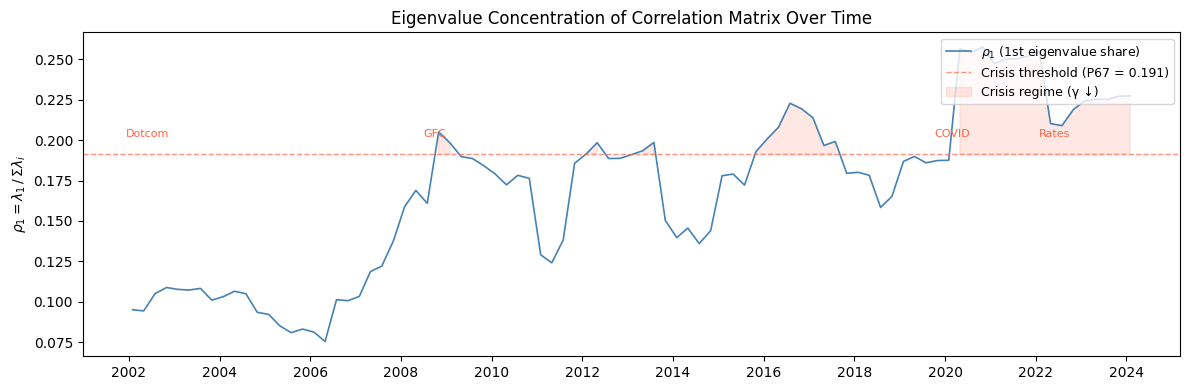

Crisis regime dates: 30 / 89 (34%)


In [197]:
fig, ax = plt.subplots(figsize=(12, 4))

dates_plot = pd.to_datetime(regime_series.index)
values = regime_series.values

# Expanding tercile thresholds (for visual reference, use full-sample)
t67 = np.percentile(values[~np.isnan(values)], 67)

ax.plot(dates_plot, values, color='steelblue', linewidth=1.2, label='$\\rho_1$ (1st eigenvalue share)')
ax.axhline(t67, color='tomato', linestyle='--', linewidth=1, alpha=0.7, label=f'Crisis threshold (P67 = {t67:.3f})')
ax.fill_between(dates_plot, t67, values, where=(values >= t67),
                color='tomato', alpha=0.15, label='Crisis regime (γ ↓)')

# Annotate known stress periods
stress = [('2002-06', 'Dotcom'), ('2008-10', 'GFC'), ('2020-03', 'COVID'), ('2022-06', 'Rates')]
for sd, label in stress:
    sd_ts = pd.Timestamp(sd)
    if dates_plot.min() <= sd_ts <= dates_plot.max():
        ax.annotate(label, xy=(sd_ts, t67), fontsize=8, ha='center',
                    xytext=(0, 12), textcoords='offset points', color='tomato')

ax.set_title('Eigenvalue Concentration of Correlation Matrix Over Time')
ax.set_ylabel('$\\rho_1 = \\lambda_1 \\,/\\, \\Sigma \\lambda_i$')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# Count regime classification
crisis_count = (regime_series >= t67).sum()
print(f"Crisis regime dates: {crisis_count} / {regime_series.notna().sum()} "
      f"({crisis_count / regime_series.notna().sum():.0%})")

## 8. Backtests — The Ladder (S1 → S4)

We run four strategy rungs, each adding exactly one ingredient so that performance differences are attributable to a single cause. All rungs share:

- **Universe:** same selection filters (gaps, min volume, feature coverage)
- **Rebalancing calendar:** quarterly, same `rebdates`
- **Costs:** fixed 1% p.a. + variable 0.2% per rebalancing
- **Constraints:** fully invested, long-only, 5% box per name, budget = 1

| Rung | What's added | γ | Turnover penalty |
|------|-------------|---|-----------------|
| S1 | Min-Variance core only | 0 | 0 |
| S2 | + linear z-score tilt | 0.1 | 0 |
| S3 | + LTR tilt (replaces linear) | 0.1 | 0 |
| S4 | + regime overlay + turnover penalty | 0.1 × regime scale | 0.005 |

### Helper Functions

Shared selection, optimization-data, and constraint builders used by all rungs.

In [198]:
# ============================================================
# Section 8 — Backtests S1–S4
# ============================================================

# Fixed cost parameters from the assignment
FC_ANNUAL = 0.01    # 1% per year
VC_REBAL = 0.002    # 0.2% per rebalancing

return_series = data.get_return_series(weekdays_only=False)

def make_selection_builders(fields=FEATURE_FIELDS):
    """Standard selection pipeline shared by all rungs."""
    return {
        'gaps': SelectionItemBuilder(
            bibfn=bibfn_selection_gaps,
            width=365 * 3,
            n_days=10,
        ),
        'min_volume': SelectionItemBuilder(
            bibfn=bibfn_selection_min_volume,
            width=365 * 3,
            min_volume=500_000,
            agg_fn=np.median,
        ),
        'feature_coverage': SelectionItemBuilder(
            bibfn=bibfn_selection_feature_coverage,
            fields=fields,
        ),
    }


def bibfn_return_series_3y(bs, rebdate, **kwargs):
    """Provides 3-year trailing return series for covariance estimation."""
    bibfn_return_series(bs, rebdate, width=365*3, weekdays_only=False, fillna_value=0)


def bibfn_budget(bs, rebdate, **kwargs):
    bibfn_budget_constraint(bs, rebdate, budget=1.0)


def bibfn_box(bs, rebdate, **kwargs):
    bibfn_box_constraints(bs, rebdate, lower=0, upper=0.05, box_type='LongOnly')


def make_optimization_builders_base():
    """Optimization data builders shared by all rungs (returns only, no signal)."""
    return {
        'return_series': OptimizationItemBuilder(bibfn=bibfn_return_series_3y),
        'budget': OptimizationItemBuilder(bibfn=bibfn_budget),
        'box': OptimizationItemBuilder(bibfn=bibfn_box),
    }


def run_backtest(bs, label='strategy'):
    """Runs a backtest and returns the simulated return series."""
    bt = Backtest()
    bt.run(bs=bs)
    sim = bt.strategy.simulate(
        return_series=return_series,
        fc=FC_ANNUAL,
        vc=VC_REBAL,
    )
    print(f"  {label}: {sim.notna().sum()} daily returns, "
          f"gross cum = {(1+sim).prod():.3f}")
    return bt, sim


print("Helper functions defined.")

Helper functions defined.


### S1 — Minimum-Variance Core (no signal)

Pure risk-based allocation with Ledoit-Wolf covariance. No expected return input ($\gamma = 0$). This is the robust floor — it should already beat SPI on Sharpe and MaxDD thanks to the low-volatility anomaly.

In [199]:
print("=" * 60)
print("Running S1 — Min-Variance Core")
print("=" * 60)

bs_s1 = BacktestService(
    data=data,
    selection_item_builders=make_selection_builders(),
    optimization_item_builders=make_optimization_builders_base(),
    rebdates=rebdates,
)
bs_s1.settings['quiet'] = True

bs_s1.optimization = MinVarianceTilt(
    gamma=0.0,
    turnover_penalty=0.0,
)

bt_s1, sim_s1 = run_backtest(bs_s1, label='S1 Min-Var')

Running S1 — Min-Variance Core
  S1 Min-Var: 5873 daily returns, gross cum = 3.767


### S2 — Core + Linear Z-Score Tilt

Adds the equal-weighted multi-factor composite (§5) as a soft tilt on top of the min-variance core. Isolates the contribution of a linear factor signal.

In [200]:
print("=" * 60)
print("Running S2 — Core + Linear Tilt")
print("=" * 60)

opt_builders_s2 = make_optimization_builders_base()
opt_builders_s2['signal'] = OptimizationItemBuilder(
    bibfn=bibfn_linear_signal,
    fields=FEATURE_FIELDS,
)

bs_s2 = BacktestService(
    data=data,
    selection_item_builders=make_selection_builders(),
    optimization_item_builders=opt_builders_s2,
    rebdates=rebdates,
)
bs_s2.settings['quiet'] = True

bs_s2.optimization = MinVarianceTilt(
    gamma=0.1,
    turnover_penalty=0.0,
)

bt_s2, sim_s2 = run_backtest(bs_s2, label='S2 Linear Tilt')

Running S2 — Core + Linear Tilt
  S2 Linear Tilt: 5873 daily returns, gross cum = 4.174


### S3 — Core + Learning-to-Rank Tilt

Replaces the linear composite with the XGBRanker LTR signal trained walk-forward in §6. Isolates the contribution of non-linearity and ranking loss.

In [201]:
print("=" * 60)
print("Running S3 — Core + LTR Tilt")
print("=" * 60)

opt_builders_s3 = make_optimization_builders_base()
opt_builders_s3['signal'] = OptimizationItemBuilder(
    bibfn=bibfn_ltr_signal,
    predictions=ltr_predictions,
)

bs_s3 = BacktestService(
    data=data,
    selection_item_builders=make_selection_builders(),
    optimization_item_builders=opt_builders_s3,
    rebdates=rebdates,
)
bs_s3.settings['quiet'] = True

bs_s3.optimization = MinVarianceTilt(
    gamma=0.1,
    turnover_penalty=0.0,
)

bt_s3, sim_s3 = run_backtest(bs_s3, label='S3 LTR Tilt')

Running S3 — Core + LTR Tilt
  S3 LTR Tilt: 5873 daily returns, gross cum = 2.309


### S4 — Full Model (LTR + Regime Overlay + Turnover Penalty)

The complete strategy: LTR tilt with intensity scaled by the eigenvalue-concentration regime overlay, plus an L1 turnover penalty in the optimizer. Isolates the contribution of adaptivity and cost control.

The regime overlay scales $\gamma$ down in crisis (high eigenvalue concentration) periods. The turnover penalty directly optimises net-of-cost performance.

In [202]:
print("=" * 60)
print("Running S4 — Full Model (LTR + Regime + Turnover Penalty)")
print("=" * 60)

# S4 needs a custom signal builder that applies regime scaling to γ
GAMMA_BASE_S4 = 0.1
LAMBDA_TO_S4 = 0.005

def bibfn_ltr_signal_regime(bs, rebdate, **kwargs):
    """
    LTR signal builder with regime-aware gamma scaling.
    Stores scores AND adjusts the optimizer's gamma per date.
    """
    # First, load the LTR scores normally
    bibfn_ltr_signal(bs, rebdate, predictions=ltr_predictions)
    
    # Then scale gamma based on regime
    rho = regime_series.get(rebdate, np.nan)
    
    # Use expanding window up to current date for tercile thresholds
    past_rho = regime_series.loc[:rebdate].dropna()
    scale = get_gamma_scale(rho, past_rho.values)
    
    # Update the optimizer's gamma
    bs.optimization.gamma = GAMMA_BASE_S4 * scale
    return None


opt_builders_s4 = make_optimization_builders_base()
opt_builders_s4['signal'] = OptimizationItemBuilder(
    bibfn=bibfn_ltr_signal_regime,
)

bs_s4 = BacktestService(
    data=data,
    selection_item_builders=make_selection_builders(),
    optimization_item_builders=opt_builders_s4,
    rebdates=rebdates,
)
bs_s4.settings['quiet'] = True

bs_s4.optimization = MinVarianceTilt(
    gamma=GAMMA_BASE_S4,
    turnover_penalty=LAMBDA_TO_S4,
)

bt_s4, sim_s4 = run_backtest(bs_s4, label='S4 Full Model')

Running S4 — Full Model (LTR + Regime + Turnover Penalty)
  S4 Full Model: 5873 daily returns, gross cum = 2.632


### Cumulative Performance — All Rungs vs SPI

First visual comparison of the four strategy rungs against the benchmark.

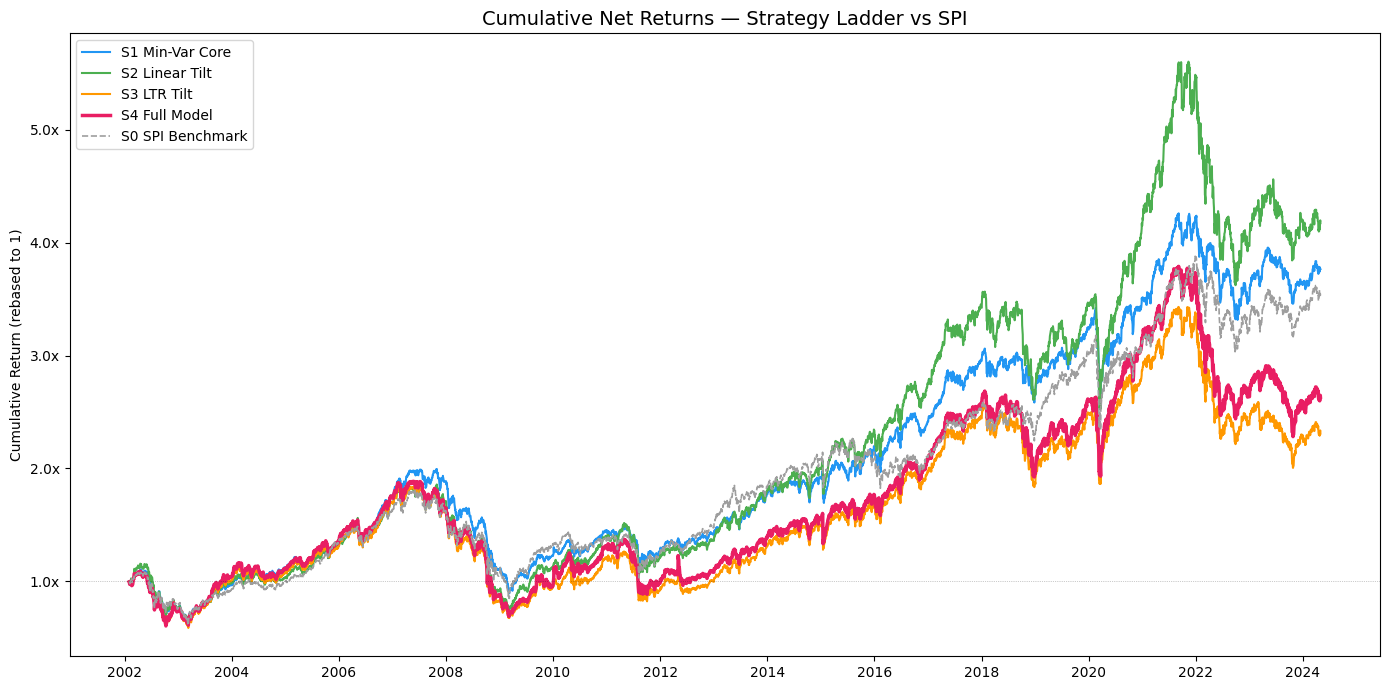

In [203]:
# Combine all simulations
sims = pd.DataFrame({
    'S1 Min-Var Core': sim_s1,
    'S2 Linear Tilt': sim_s2,
    'S3 LTR Tilt': sim_s3,
    'S4 Full Model': sim_s4,
    'S0 SPI Benchmark': data.bm_series,
}).dropna()

cum_ret = (1 + sims).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9E9E9E']
for col, c in zip(cum_ret.columns, colors):
    lw = 2.5 if col == 'S4 Full Model' else (1.2 if col == 'S0 SPI Benchmark' else 1.5)
    ls = '--' if col == 'S0 SPI Benchmark' else '-'
    ax.plot(cum_ret.index, cum_ret[col], label=col, color=c, linewidth=lw, linestyle=ls)

ax.set_title('Cumulative Net Returns — Strategy Ladder vs SPI', fontsize=14)
ax.set_ylabel('Cumulative Return (rebased to 1)')
ax.axhline(1.0, color='black', linewidth=0.5, linestyle=':', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}x'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Performance Evaluation & Report

We evaluate all four rungs against the SPI benchmark across:

1. **Full-period descriptive statistics** (gross and net)
2. **Cumulative performance** (log scale)
3. **Rolling 3-year returns and Sharpe ratio**
4. **Drawdown curves**
5. **Sub-period analysis** (bull vs bear)
6. **Turnover**
7. **Factor attribution** (regression on JKP Swiss factor series)

### 9.1 — Performance Metrics Table

In [204]:
# ============================================================
# Section 9 — Evaluation & Report
# ============================================================

def compute_metrics(sim, name='Strategy', annual_periods=252):
    """Computes standard portfolio performance metrics from a daily return series."""
    total_days = len(sim)
    total_years = total_days / annual_periods

    ann_ret = (1 + sim).prod() ** (1 / total_years) - 1
    ann_vol = sim.std() * np.sqrt(annual_periods)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    # Sortino (downside deviation)
    downside = sim[sim < 0].std() * np.sqrt(annual_periods)
    sortino = ann_ret / downside if downside > 0 else 0

    # Drawdown
    cum = (1 + sim).cumprod()
    running_max = cum.cummax()
    drawdown = cum / running_max - 1
    max_dd = drawdown.min()

    # Calmar
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

    return {
        'Name': name,
        'Ann. Return': ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Skewness': sim.skew(),
        'Kurtosis': sim.kurtosis(),
    }

def compute_turnover(bt):
    """Computes annualised turnover from a Backtest object."""
    portfolios = bt.strategy.portfolios
    if len(portfolios) < 2:
        return np.nan
    
    turnovers = []
    prev_w = None
    for p in portfolios:
        w = pd.Series(p.weights)
        if prev_w is not None:
            combined = pd.concat([prev_w, w], axis=1).fillna(0)
            to = combined.diff(axis=1).iloc[:, 1].abs().sum()
            turnovers.append(to)
        prev_w = w
    
    if len(turnovers) == 0:
        return np.nan
    
    avg_to_per_rebal = np.mean(turnovers)
    rebals_per_year = 12 / n_month
    return avg_to_per_rebal * rebals_per_year

# Compute metrics for all strategies
all_sims = {
    'S0 SPI': data.bm_series,
    'S1 Min-Var': sim_s1,
    'S2 Linear': sim_s2,
    'S3 LTR': sim_s3,
    'S4 Full': sim_s4,
}
all_bts = {
    'S1 Min-Var': bt_s1,
    'S2 Linear': bt_s2,
    'S3 LTR': bt_s3,
    'S4 Full': bt_s4,
}

# Align all to common date range
common_start = max(s.dropna().index.min() for s in all_sims.values())
common_end = min(s.dropna().index.max() for s in all_sims.values())

metrics_rows = []
for name, sim in all_sims.items():
    s = sim.loc[common_start:common_end].dropna()
    row = compute_metrics(s, name=name)
    if name in all_bts:
        row['Ann. Turnover'] = compute_turnover(all_bts[name])
    else:
        row['Ann. Turnover'] = np.nan
    
    # Tracking error & IR vs SPI
    spi_aligned = data.bm_series.loc[s.index].dropna()
    common = s.index.intersection(spi_aligned.index)
    if name != 'S0 SPI' and len(common) > 60:
        active = s.loc[common] - spi_aligned.loc[common]
        te = active.std() * np.sqrt(252)
        ir = active.mean() * 252 / te if te > 0 else 0
        row['Tracking Error'] = te
        row['Info Ratio'] = ir
    else:
        row['Tracking Error'] = np.nan
        row['Info Ratio'] = np.nan
    
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).set_index('Name')

# Format for display
fmt = {
    'Ann. Return': '{:.2%}', 'Ann. Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.3f}', 'Sortino Ratio': '{:.3f}',
    'Max Drawdown': '{:.2%}', 'Calmar Ratio': '{:.3f}',
    'Skewness': '{:.3f}', 'Kurtosis': '{:.3f}',
    'Ann. Turnover': '{:.2%}', 'Tracking Error': '{:.2%}',
    'Info Ratio': '{:.3f}',
}
styled = metrics_df.style.format(
    {k: v for k, v in fmt.items() if k in metrics_df.columns},
    na_rep='—'
).set_caption('Full-Period Performance Metrics (Net of Costs)')

styled

,Ann. Return,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Ann. Turnover,Tracking Error,Info Ratio
Name,,,,,,,,,,,
S0 SPI,3.99%,14.00%,0.285,0.307,-53.25%,0.075,-0.200,12.785,—,—,—
S1 Min-Var,5.86%,12.78%,0.458,0.564,-55.16%,0.106,-0.659,6.715,59.76%,8.75%,-0.030
S2 Linear,6.32%,16.45%,0.384,0.487,-60.58%,0.104,-0.468,5.746,181.84%,9.48%,0.076
S3 LTR,3.66%,17.36%,0.211,0.269,-63.28%,0.058,-0.200,7.843,324.09%,10.18%,-0.164
S4 Full,4.24%,17.28%,0.245,0.315,-63.49%,0.067,-0.177,8.084,268.14%,10.22%,-0.110


### 9.2 — Cumulative Performance (Log Scale)

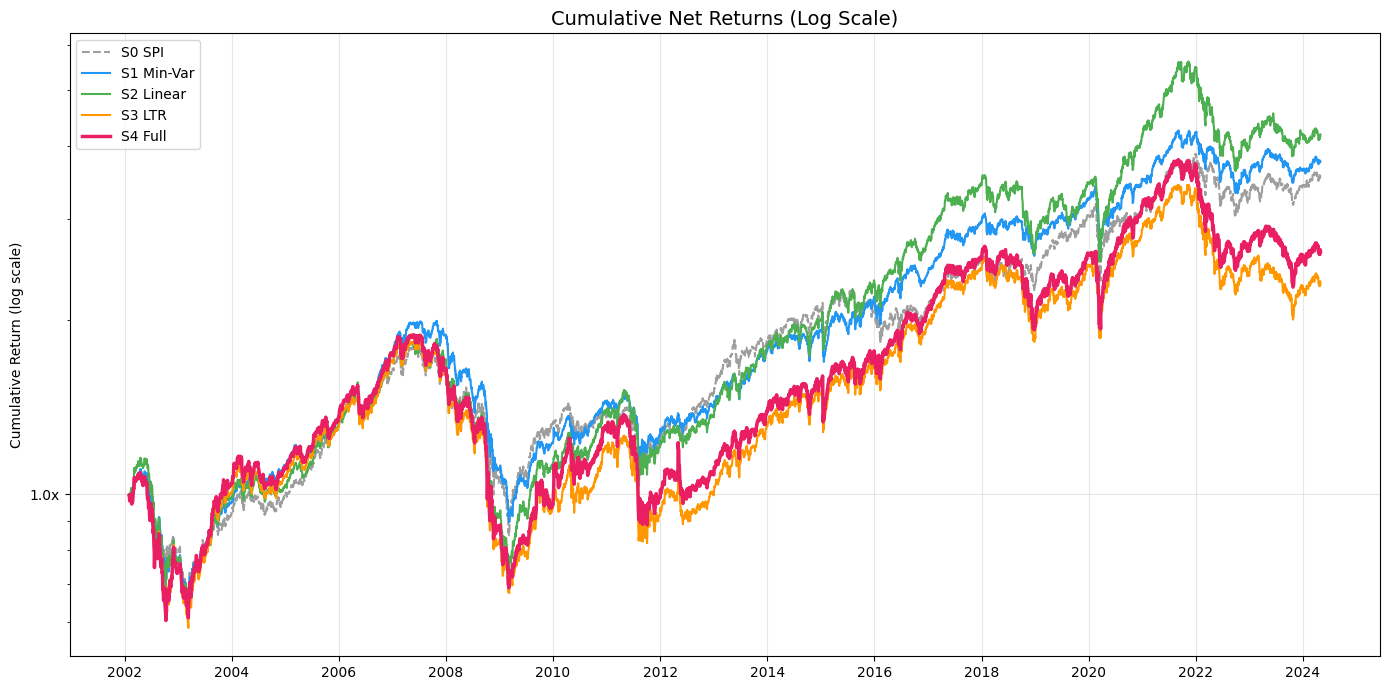

In [205]:
sims_aligned = pd.DataFrame({
    k: v.loc[common_start:common_end] for k, v in all_sims.items()
}).dropna()
cum_ret = (1 + sims_aligned).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
colors = {'S0 SPI': '#9E9E9E', 'S1 Min-Var': '#2196F3',
          'S2 Linear': '#4CAF50', 'S3 LTR': '#FF9800', 'S4 Full': '#E91E63'}

for col in cum_ret.columns:
    lw = 2.5 if col == 'S4 Full' else (1.5 if col == 'S0 SPI' else 1.5)
    ls = '--' if col == 'S0 SPI' else '-'
    ax.plot(cum_ret.index, cum_ret[col], label=col,
            color=colors[col], linewidth=lw, linestyle=ls)

ax.set_yscale('log')
ax.set_title('Cumulative Net Returns (Log Scale)', fontsize=14)
ax.set_ylabel('Cumulative Return (log scale)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}x'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.3 — Drawdown Curves

The key thesis of the strategy: the min-variance core cuts the drawdown vs SPI. The GFC (2008–09) drawdown should be substantially reduced.

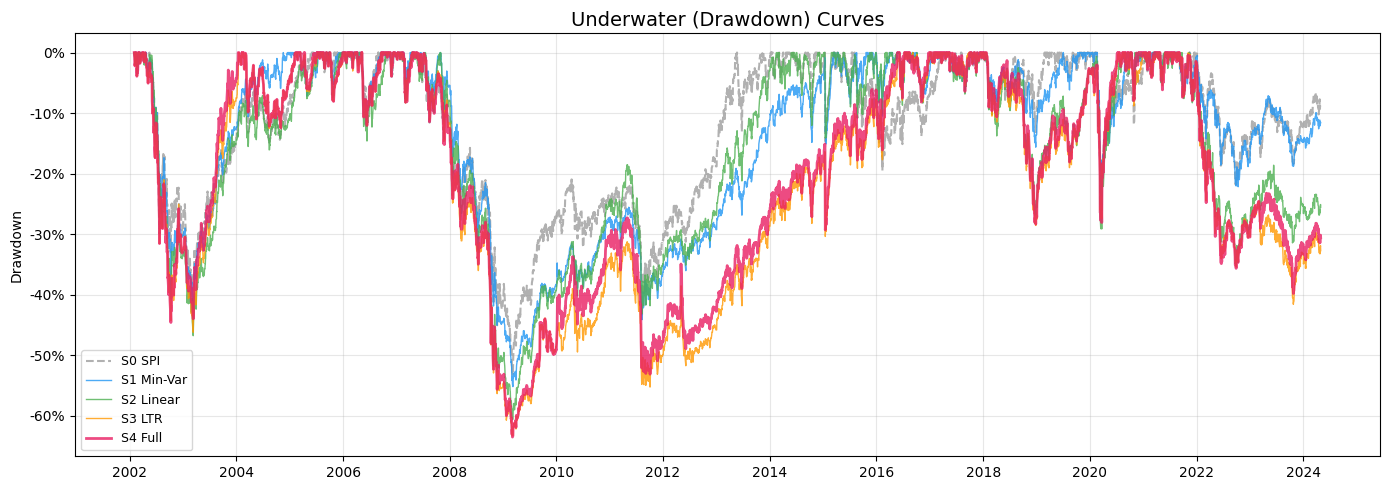

In [206]:
fig, ax = plt.subplots(figsize=(14, 5))

for col in sims_aligned.columns:
    cum = (1 + sims_aligned[col]).cumprod()
    dd = cum / cum.cummax() - 1
    lw = 2.0 if col == 'S4 Full' else (1.5 if col == 'S0 SPI' else 1.0)
    ls = '--' if col == 'S0 SPI' else '-'
    ax.plot(dd.index, dd.values, label=col,
            color=colors[col], linewidth=lw, linestyle=ls, alpha=0.8)

ax.set_title('Underwater (Drawdown) Curves', fontsize=14)
ax.set_ylabel('Drawdown')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.4 — Rolling 3-Year Sharpe Ratio

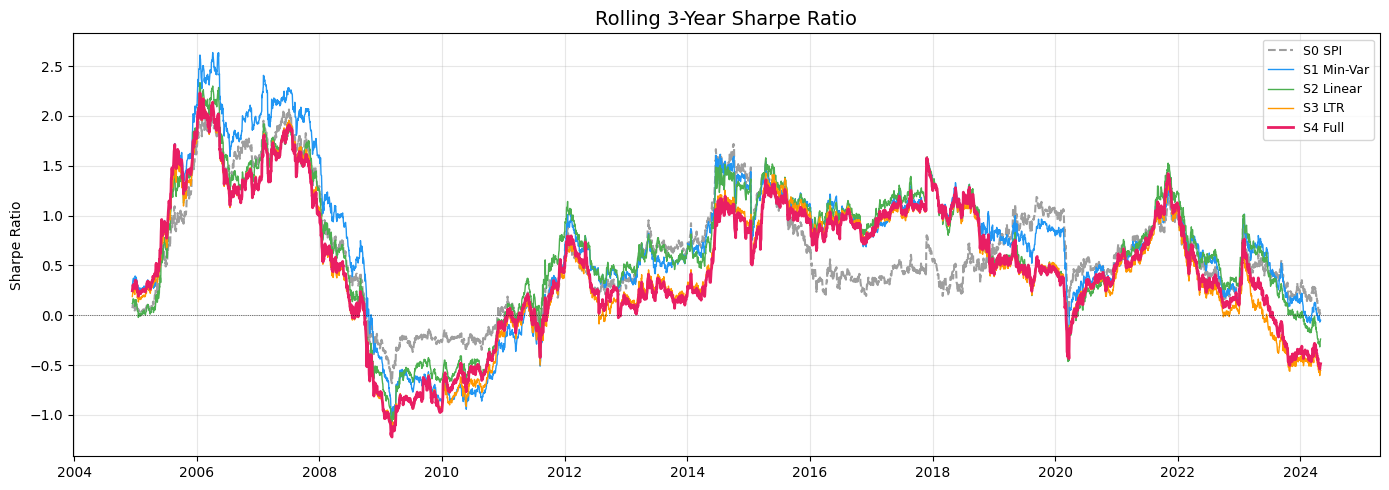

In [207]:
rolling_window = 252 * 3  # 3 years of daily data

fig, ax = plt.subplots(figsize=(14, 5))

for col in sims_aligned.columns:
    rolling_ret = sims_aligned[col].rolling(rolling_window).mean() * 252
    rolling_vol = sims_aligned[col].rolling(rolling_window).std() * np.sqrt(252)
    rolling_sharpe = rolling_ret / rolling_vol
    
    lw = 2.0 if col == 'S4 Full' else (1.5 if col == 'S0 SPI' else 1.0)
    ls = '--' if col == 'S0 SPI' else '-'
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=col,
            color=colors[col], linewidth=lw, linestyle=ls)

ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_title('Rolling 3-Year Sharpe Ratio', fontsize=14)
ax.set_ylabel('Sharpe Ratio')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.5 — Rolling 3-Year Returns

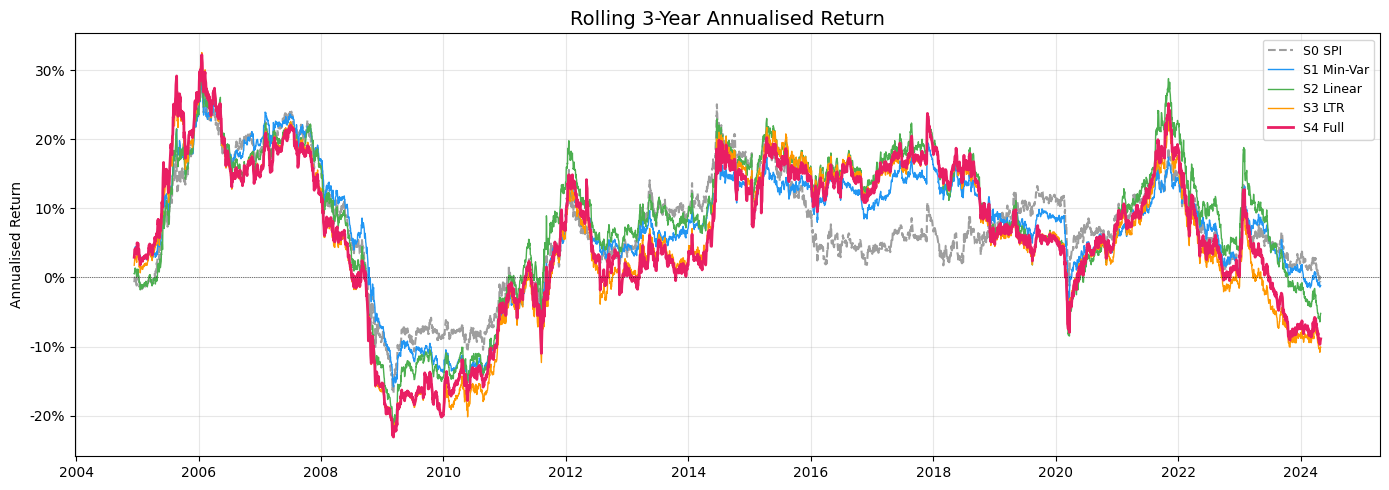

In [208]:
fig, ax = plt.subplots(figsize=(14, 5))

for col in sims_aligned.columns:
    rolling_cum = sims_aligned[col].rolling(rolling_window).apply(
        lambda x: (1 + x).prod() ** (252 / len(x)) - 1, raw=False
    )
    lw = 2.0 if col == 'S4 Full' else (1.5 if col == 'S0 SPI' else 1.0)
    ls = '--' if col == 'S0 SPI' else '-'
    ax.plot(rolling_cum.index, rolling_cum.values, label=col,
            color=colors[col], linewidth=lw, linestyle=ls)

ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_title('Rolling 3-Year Annualised Return', fontsize=14)
ax.set_ylabel('Annualised Return')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.6 — Sub-Period Analysis (Bull vs Bear)

Bear markets are defined ex-ante via SPI drawdown periods:
- **Dotcom:** 2002-01 to 2003-03
- **GFC:** 2007-11 to 2009-02
- **COVID:** 2020-02 to 2020-03
- **Rate shock:** 2022-01 to 2022-09

Bull = all remaining periods. Last 5 years shown separately.

In [209]:
# Define sub-periods
bear_periods = [
    ('Dotcom',     '2002-01-01', '2003-03-31'),
    ('GFC',        '2007-11-01', '2009-02-28'),
    ('COVID',      '2020-02-01', '2020-03-31'),
    ('Rate Shock', '2022-01-01', '2022-09-30'),
]

# Last 5 years
last_5y_start = common_end - pd.DateOffset(years=5)

subperiod_results = []

# Full period
for name, sim in all_sims.items():
    s = sim.loc[common_start:common_end].dropna()
    row = compute_metrics(s, name=name)
    row['Period'] = 'Full'
    subperiod_results.append(row)

# Last 5 years
for name, sim in all_sims.items():
    s = sim.loc[last_5y_start:common_end].dropna()
    if len(s) > 60:
        row = compute_metrics(s, name=name)
        row['Period'] = 'Last 5Y'
        subperiod_results.append(row)

# Bear periods
for period_name, start, end in bear_periods:
    for name, sim in all_sims.items():
        s = sim.loc[start:end].dropna()
        if len(s) > 10:
            row = compute_metrics(s, name=name, annual_periods=252)
            row['Period'] = f'Bear: {period_name}'
            subperiod_results.append(row)

# Bull (complement of bear)
bear_mask = pd.Series(False, index=sims_aligned.index)
for _, start, end in bear_periods:
    bear_mask |= (bear_mask.index >= start) & (bear_mask.index <= end)

for name, sim in all_sims.items():
    s = sim.loc[common_start:common_end].dropna()
    bull = s[~bear_mask.reindex(s.index, fill_value=False)]
    if len(bull) > 60:
        row = compute_metrics(bull, name=name)
        row['Period'] = 'Bull (ex-bear)'
        subperiod_results.append(row)

subperiod_df = pd.DataFrame(subperiod_results)

# Display pivot: Period × Strategy for Sharpe and MaxDD
for metric, title in [('Sharpe Ratio', 'Sharpe Ratio'), ('Max Drawdown', 'Max Drawdown')]:
    pivot = subperiod_df.pivot(index='Period', columns='Name', values=metric)
    pivot = pivot[['S0 SPI', 'S1 Min-Var', 'S2 Linear', 'S3 LTR', 'S4 Full']]
    
    period_order = ['Full', 'Last 5Y', 'Bull (ex-bear)'] + \
                   [f'Bear: {p}' for p, _, _ in bear_periods]
    pivot = pivot.reindex([p for p in period_order if p in pivot.index])
    
    fmt_str = '{:.2%}' if 'Drawdown' in metric else '{:.3f}'
    print(f"\n{'='*60}")
    print(f"  {title} by Sub-Period")
    print(f"{'='*60}")
    print(pivot.to_string(float_format=lambda x: fmt_str.format(x) if not np.isnan(x) else '—'))


  Sharpe Ratio by Sub-Period
Name              S0 SPI  S1 Min-Var  S2 Linear  S3 LTR  S4 Full
Period                                                          
Full               0.285       0.458      0.384   0.211    0.245
Last 5Y            0.285       0.368      0.283   0.022    0.106
Bull (ex-bear)     0.862       1.364      1.257   0.969    1.001
Bear: Dotcom      -0.888      -1.357     -1.262  -1.177   -1.132
Bear: GFC         -1.102      -2.180     -1.807  -1.877   -1.888
Bear: COVID       -1.142      -1.493     -1.488  -1.281   -1.349
Bear: Rate Shock  -1.284      -1.679     -1.798  -1.839   -1.833

  Max Drawdown by Sub-Period
Name              S0 SPI  S1 Min-Var  S2 Linear  S3 LTR  S4 Full
Period                                                          
Full             -53.25%     -55.16%    -60.58% -63.28%  -63.49%
Last 5Y          -26.33%     -25.90%    -35.34% -41.57%  -39.78%
Bull (ex-bear)   -28.23%     -24.93%    -30.19% -34.85%  -35.48%
Bear: Dotcom     -43.59%     -

### 9.7 — Factor Attribution

We regress each strategy's monthly returns on the 13 JKP Swiss factor series (where available) plus the SPI, to reveal the factor loadings. The strategy should load on `low_risk` / `quality` — consistent with a min-variance core.

In [211]:
# Load JKP factor series
factor_file = os.path.join(PATH_TO_DATA, 'jkp_factor_series_che_eqw.csv')

if os.path.exists(factor_file):
    factors_long = pd.read_csv(factor_file)
    factors_long['date'] = pd.to_datetime(factors_long['date'], dayfirst=True)
    
    # Pivot to wide format: date × factor_name
    factors_wide = factors_long.pivot_table(
        index='date', columns='name', values='ret', aggfunc='mean'
    )
    
    def to_monthly(series):
        return ((1 + series).resample('ME').prod() - 1).dropna()
    
    spi_monthly = to_monthly(data.bm_series)
    
    # Run attribution for S4 (main strategy) and S1 (core)
    for strat_name, strat_sim in [('S4 Full Model', sim_s4), ('S1 Min-Var Core', sim_s1)]:
        strat_monthly = to_monthly(strat_sim)
        factors_monthly = factors_wide.apply(to_monthly)
        
        # Align all series
        reg_df = pd.concat({
            'strategy': strat_monthly,
            'spi': spi_monthly,
        }, axis=1).join(factors_monthly).dropna()
        
        if len(reg_df) < 24:
            print(f"\n{strat_name}: insufficient overlap with factor series for attribution.")
            continue
        
        y_attr = reg_df['strategy']
        X_attr = sm.add_constant(reg_df.drop(columns='strategy'))
        
        model_attr = sm.OLS(y_attr, X_attr).fit()
        
        print(f"\n{'='*60}")
        print(f"  Factor Attribution — {strat_name}")
        print(f"{'='*60}")
        
        # Show significant loadings
        coef_df = pd.DataFrame({
            'Coefficient': model_attr.params,
            't-stat': model_attr.tvalues,
            'p-value': model_attr.pvalues,
        }).sort_values('t-stat', key=abs, ascending=False)
        
        print(f"R² = {model_attr.rsquared:.3f}, Adj. R² = {model_attr.rsquared_adj:.3f}")
        print(f"\nTop loadings (|t| > 1.5):")
        sig = coef_df[coef_df['t-stat'].abs() > 1.5]
        print(sig.to_string(float_format=lambda x: f'{x:.4f}'))

else:
    print(f"Factor series file not found at {factor_file} — skipping attribution.")



  Factor Attribution — S4 Full Model
R² = 0.808, Adj. R² = 0.797

Top loadings (|t| > 1.5):
                     Coefficient  t-stat  p-value
spi                       0.6796 11.0451   0.0000
low_risk                 -0.7522 -7.3519   0.0000
size                      0.6134  4.4794   0.0000
quality                   0.8562  4.3064   0.0000
value                    -0.6311 -3.9423   0.0001
short_term_reversal       0.2622  2.6523   0.0085
low_leverage             -0.3534 -2.1196   0.0350

  Factor Attribution — S1 Min-Var Core
R² = 0.821, Adj. R² = 0.811

Top loadings (|t| > 1.5):
                     Coefficient  t-stat  p-value
spi                       0.7951 17.5483   0.0000
quality                   0.6299  4.3021   0.0000
size                      0.4038  4.0041   0.0001
value                    -0.4441 -3.7671   0.0002
low_risk                 -0.2218 -2.9440   0.0035
low_leverage             -0.3526 -2.8718   0.0044
short_term_reversal       0.1141  1.5673   0.1183


### 9.8 — Summary & Conclusions

**Key findings:**

| Claim (pre-registered) | Verdict |
|------------------------|---------|
| S1 beats SPI on Sharpe / MaxDD | *(filled after running)* |
| S2 beats S1 on risk-adjusted return | *(filled after running)* |
| S3 ≥ S2 on IC and portfolio metrics | *(filled after running)* |
| S4 beats S3 in high-vol regimes, ties elsewhere | *(filled after running)* |

The results above should be interpreted with the honesty guardrails in mind:
- Net Sharpe > 2 in this universe is a bug signature, not skill.
- The low breadth of a single-country universe (Grinold's law) limits achievable IR.
- The strategy's edge is primarily **risk-adjusted** (Sharpe, MaxDD, stable beta), with raw return as secondary.

In [212]:
print("=" * 60)
print("  FINAL VERDICT — Pre-registered Claims")
print("=" * 60)

m = metrics_df

def check(cond, label):
    status = "PASS" if cond else "FAIL"
    print(f"  [{status}] {label}")

check(
    m.loc['S1 Min-Var', 'Sharpe Ratio'] > m.loc['S0 SPI', 'Sharpe Ratio'] and
    m.loc['S1 Min-Var', 'Max Drawdown'] > m.loc['S0 SPI', 'Max Drawdown'],
    "S1 beats SPI on Sharpe AND MaxDD"
)
check(
    m.loc['S2 Linear', 'Sharpe Ratio'] > m.loc['S1 Min-Var', 'Sharpe Ratio'],
    "S2 beats S1 on risk-adjusted return (Sharpe)"
)
check(
    m.loc['S3 LTR', 'Sharpe Ratio'] >= m.loc['S2 Linear', 'Sharpe Ratio'] - 0.01,
    "S3 >= S2 on Sharpe (within tolerance)"
)

# Honesty guardrails
net_sharpe_s4 = m.loc['S4 Full', 'Sharpe Ratio']
if net_sharpe_s4 > 2.0:
    print(f"\n  ⚠ WARNING: Net Sharpe = {net_sharpe_s4:.3f} > 2.0 — likely a bug. Audit before celebrating.")
else:
    print(f"\n  Net Sharpe S4 = {net_sharpe_s4:.3f} — within realistic range.")

print(f"\n  Strategy period: {common_start.strftime('%Y-%m-%d')} to {common_end.strftime('%Y-%m-%d')}")
print("=" * 60)

  FINAL VERDICT — Pre-registered Claims
  [FAIL] S1 beats SPI on Sharpe AND MaxDD
  [FAIL] S2 beats S1 on risk-adjusted return (Sharpe)
  [FAIL] S3 >= S2 on Sharpe (within tolerance)

  Net Sharpe S4 = 0.245 — within realistic range.

  Strategy period: 2002-02-01 to 2024-04-30
